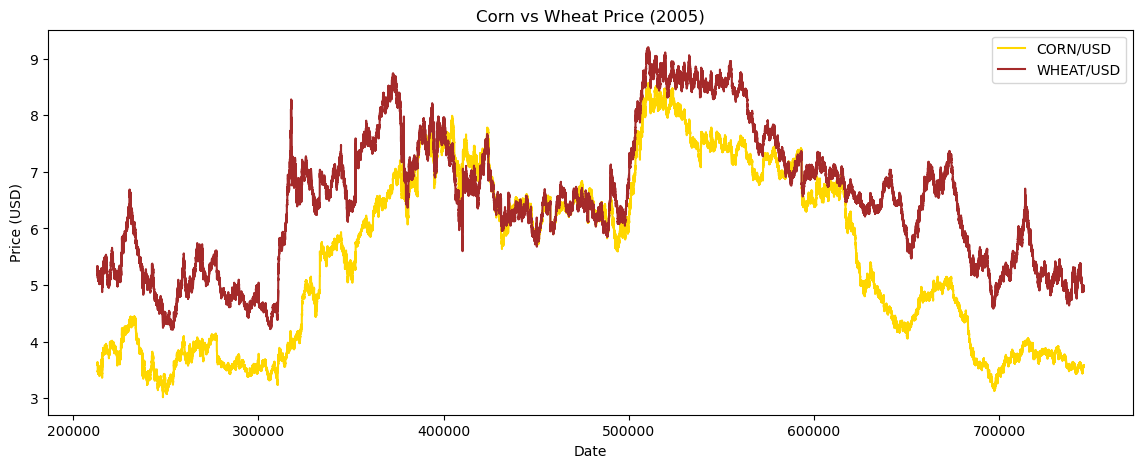

In [10]:
corn_path = 'dataset/CORN_USD_2005_2020.csv'
wheat_path = 'dataset/WHEAT_USD_2005_2020.csv'
CSV_C = 'data-scripts/data.csv'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

TEST_RATIO = 1
# ── paths ─────────────────────────────────────────────────────────────
CSV_A = 'dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = 'dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = 'data-scripts/data.csv'
CSV_D = 'data-scripts/data_one_regime.csv'
# ─────────────────────────────────────────────────────────────────────
df_as = []
df_bs = []
df_a_1 = pd.read_csv(CSV_A).dropna()
df_b_1 = pd.read_csv(CSV_B).dropna()
df_a_1 = df_a_1[int(0.2*len(df_a_1)):int(0.7*len(df_a_1))]
df_b_1 = df_b_1[int(0.2*len(df_b_1)):int(0.7*len(df_b_1))]

df_a_3 = pd.read_csv(CSV_D)[['s1']].dropna()
df_b_3 = pd.read_csv(CSV_D)[['s2']].dropna()
df_a_3 = df_a_3.rename(columns={"s1": "close"})
df_b_3 = df_b_3.rename(columns={"s2": "close"})

corn = df_a_1
wheat = df_b_1
# corn = pd.read_csv(corn_path, parse_dates=['time'], index_col='time')
# wheat = pd.read_csv(wheat_path, parse_dates=['time'], index_col='time')

plt.figure(figsize=(14, 5))
plt.plot(corn['close'], label='CORN/USD', color='gold')
plt.plot(wheat['close'], label='WHEAT/USD', color='brown')
plt.title('Corn vs Wheat Price (2005)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [11]:
# diff = corn.index[-1] - corn.index[0]
# years = diff.total_seconds() / (365.25 * 24 * 3600)
# print(years)

In [12]:
train_size = int(0.8*len(corn['close']))
train_A = corn['close'][:train_size]
train_B = wheat['close'][:train_size]
test_A = corn['close'][train_size:]
test_B = wheat['close'][train_size:]

In [13]:
def estimate_beta_OU(A, B):
    a_log = np.log(A)
    b_log = np.log(B).values.reshape(-1, 1)
    
    model = LinearRegression().fit(b_log, a_log)

    return model.coef_[0]

beta = estimate_beta_OU(train_A, train_B)

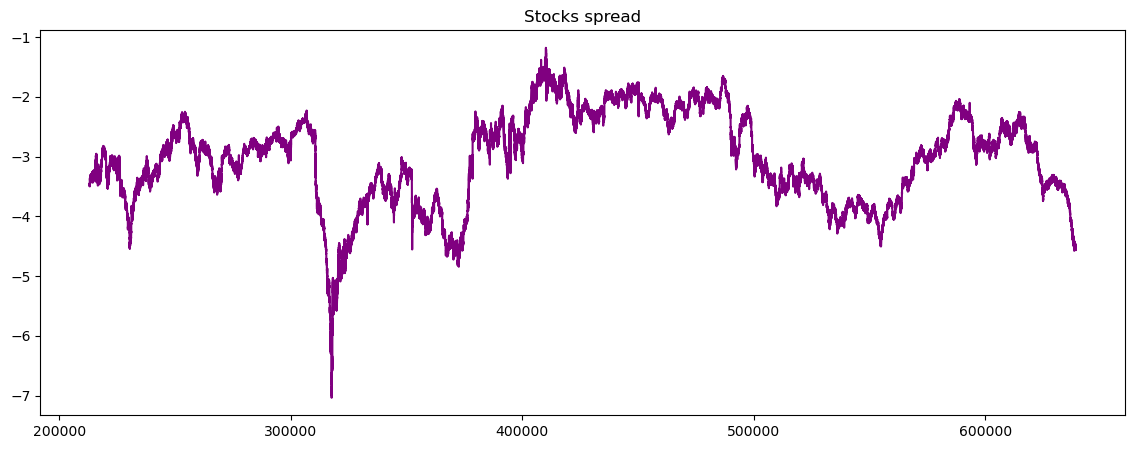

In [14]:
train_spread = train_A-beta*train_B
test_spread = test_A-beta*test_B
plt.figure(figsize=(14, 5))
plt.plot(train_spread, label='spread', color='purple')
plt.title("Stocks spread")
plt.show()

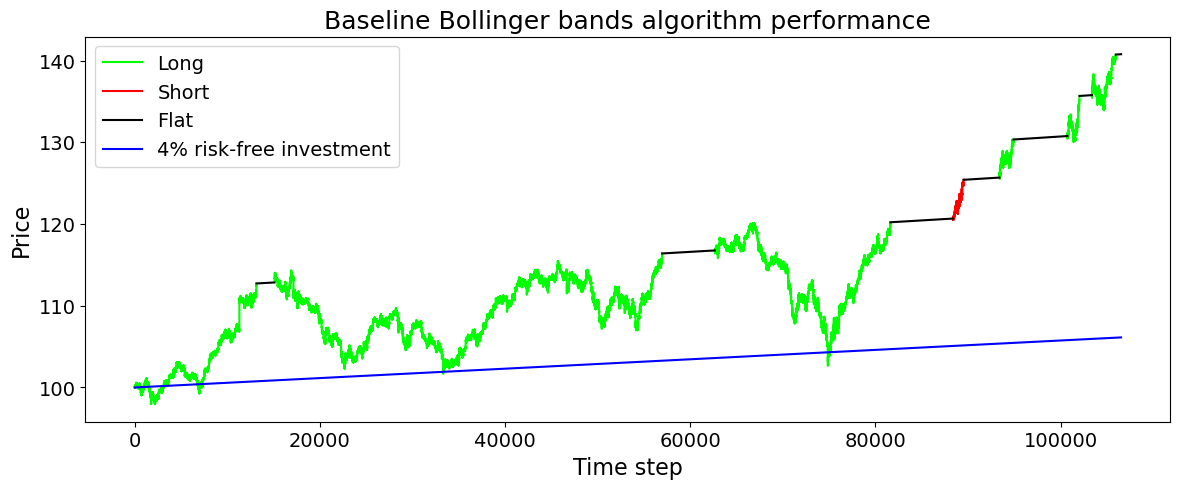

140.770155225151


In [22]:
def print_pnl(spread, stock_A, stock_B):
    positions = []
    z = 0.5
    money = 100
    mean = np.mean(train_spread)
    sd = np.std(train_spread)
    pnl = []
    position = 0
    for i in range(len(spread)):
        positions.append(position)
        curz = (spread.iloc[i]-mean)/sd
        prev_position = position
        if position < 0 and -z < curz <= 0:
            money += position * spread.iloc[i]
            position=0
        elif position > 0 and 0 <= curz < z:
            money += position*spread.iloc[i]
            position=0
        elif curz>=z:
            money += position*spread.iloc[i]
            maxpos = money/(np.abs(stock_A.iloc[i])+np.abs(beta*stock_B.iloc[i]))
            position=-maxpos
            money-=position*spread.iloc[i]
        elif curz<=-z:
            money+=position*spread.iloc[i]
            maxpos = money/(np.abs(stock_A.iloc[i])+np.abs(beta*stock_B.iloc[i]))
            position=maxpos
            money-=position*spread.iloc[i]
        if (position == prev_position and position == 0):
            money *= 1.000000558
        pnl.append(position*spread.iloc[i]+money)

    positions = np.array(positions)
    pnl = np.array(pnl)

    plt.rcParams.update({
        'font.size':        16,
        'axes.titlesize':   18,
        'axes.labelsize':   16,
        'xtick.labelsize':  14,
        'ytick.labelsize':  14,
        'legend.fontsize':  14,
    })
    
    plt.figure(figsize=(14, 5))
    # plt.plot(pnl, label='Z-score PnL', color='red')
    plt.plot(np.where(positions > 0, pnl, np.nan),
            color='lime', label='Long')

    plt.plot(np.where(positions < 0, pnl, np.nan),
            color='red', label='Short')

    plt.plot(np.where(positions == 0, pnl, np.nan),
            color='black', label='Flat')
    plt.plot(np.linspace(100, 100*(1.000000558 ** len(pnl)), len(pnl)), label="4% risk-free investment", color='blue')
    plt.legend()
    plt.title("Baseline Bollinger bands algorithm performance")
    plt.ylabel("Price")
    plt.xlabel("Time step")
    plt.show()
    return pnl

pnl = print_pnl(test_spread, test_A, test_B)
print(pnl[-1])

In [16]:
# Simpler version
df = pd.DataFrame(pnl, columns=['values'])
returns = df['values'].pct_change().dropna()
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(68000)

print(f"Annualized Sharpe Ratio: {sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 1.3223
